In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
from pathlib import Path

import getdist
import matplotlib.pyplot as plt
import numpy as np
from getdist import plots
from scipy.stats import gaussian_kde

from posterior_eigenmodes import (
    add_all_mode_derived_parameters,
    eigenmode_report,
    eigenmodes,
    get_mode_samples,
)
from posterior_eigenmodes.interpretation import (
    format_mode_direction,
    format_mode_summary,
    top_correlation_changes,
    top_eigenvector_alignments,
)


# Inputs

In [3]:
#Reference chains / covmat = Full CMB
chain_root_a = "./chains/Full/IDE/IDE_FP_BAO_SN"
covmat_a = Path("./chains/Full/IDE/IDE_FP_BAO_SN.covmat")
params_a = ["omega_b", "omega_cdm", "theta_s_1e2", "delta_DMDE"]

#Second chains / covmat = geometric CMB
chain_root_b = "./chains/Compressed/IDE/IDE_P3x3_dBAO_SN"
covmat_b = Path("./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.covmat")
params_b = ["omega_b", "omega_cdm", "theta_s_100", "delta_DMDE"]

# Let's load and plot the Chains

In [4]:
sample_a = getdist.loadMCSamples(chain_root_a, settings={"ignore_rows": 0.3})
sample_b = getdist.loadMCSamples(chain_root_b, settings={"ignore_rows": 0.3})

./chains/Full/IDE/IDE_FP_BAO_SN.1.txt
./chains/Full/IDE/IDE_FP_BAO_SN.2.txt
./chains/Full/IDE/IDE_FP_BAO_SN.3.txt
./chains/Full/IDE/IDE_FP_BAO_SN.4.txt
Removed 0.3 as burn in
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.1.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.2.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.3.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.4.txt
Removed 0.3 as burn in


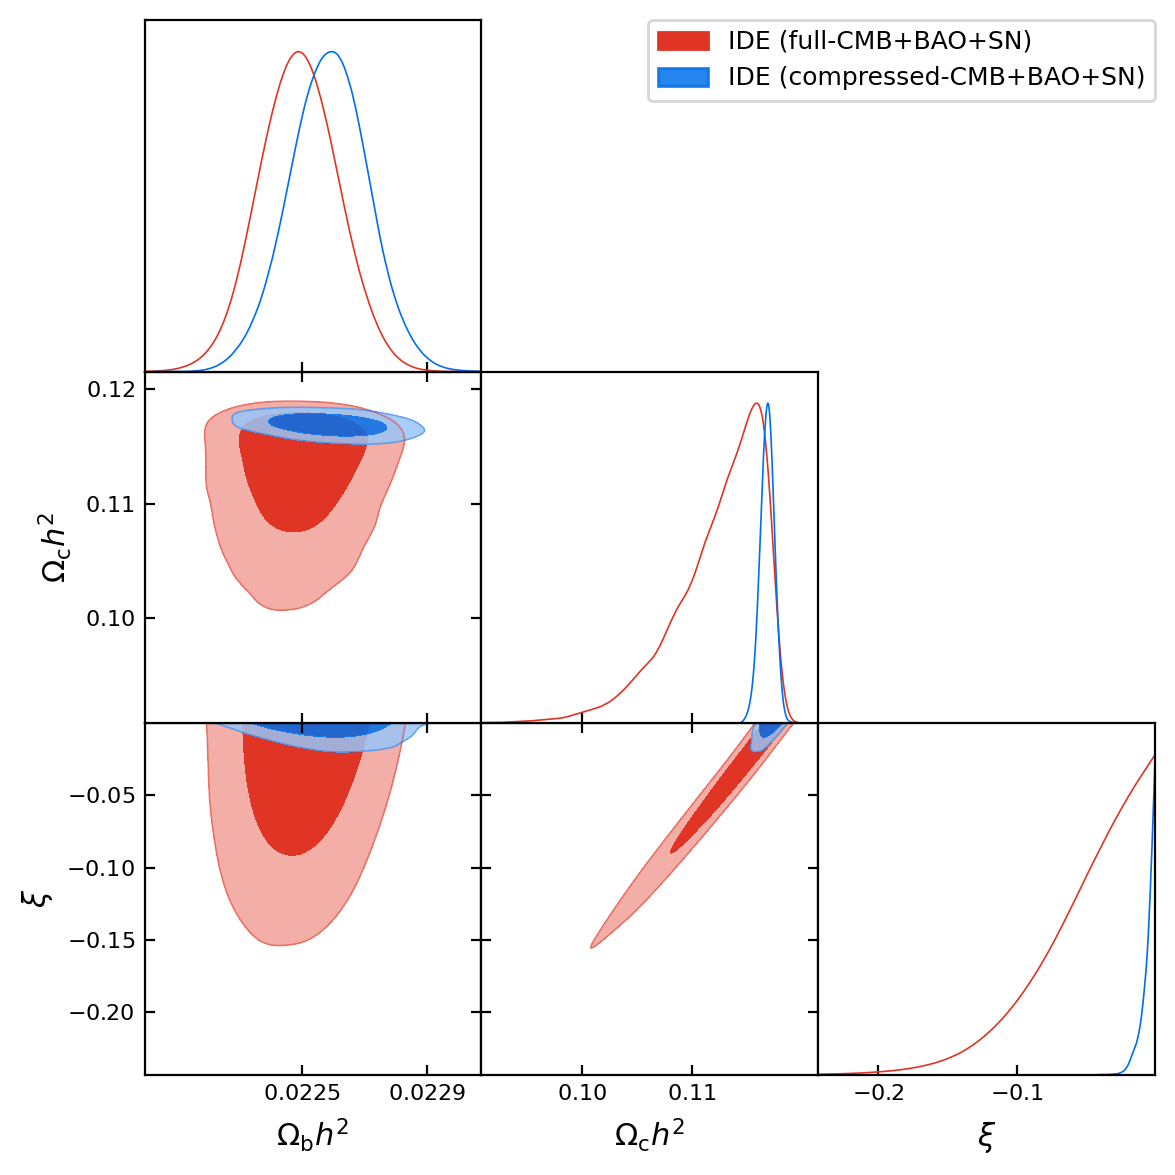

In [5]:
g = plots.get_subplot_plotter()
g.triangle_plot([sample_a, sample_b], ["omega_b", "omega_cdm", "delta_DMDE"], legend_labels=["IDE (full-CMB+BAO+SN)","IDE (compressed-CMB+BAO+SN)" ], filled=True)

# Covariance And Chain Results

In [6]:
# use this function to get the results using the Cobaya covmats.
# if chain roots are also provided, the covmat analysis is kept,
# and the chains are only used to estimate the posterior shifts.
results = eigenmodes(
    covmat_a=covmat_a,
    covmat_b=covmat_b,
    chain_root_a=chain_root_a,
    chain_root_b=chain_root_b,
    params_A=params_a,
    params_B=params_b,
)

# covmat_result


./chains/Full/IDE/IDE_FP_BAO_SN.1.txt
./chains/Full/IDE/IDE_FP_BAO_SN.2.txt
./chains/Full/IDE/IDE_FP_BAO_SN.3.txt
./chains/Full/IDE/IDE_FP_BAO_SN.4.txt
Removed 0.3 as burn in
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.1.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.2.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.3.txt
./chains/Compressed/IDE/IDE_P3x3_dBAO_SN.4.txt
Removed 0.3 as burn in


In [7]:
print(eigenmode_report(results, precision=4))

A
Reference posterior

- Mode 1
  - lambda = 0.001494
  - sigma = 0.03866
  - direction = -0.9945 delta_DMDE -0.1052 omega_cdm -0.0005 omega_b -0.0004 theta_s_1e2

- Mode 2
  - lambda = 5.341e-07
  - sigma = 0.0007308
  - direction = -0.9928 omega_cdm +0.1050 delta_DMDE +0.0435 omega_b -0.0382 theta_s_1e2

- Mode 3
  - lambda = 7.355e-08
  - sigma = 0.0002712
  - direction = 0.9973 theta_s_1e2 +0.0638 omega_b -0.0352 omega_cdm +0.0033 delta_DMDE

- Mode 4
  - lambda = 1.455e-08
  - sigma = 0.0001206
  - direction = 0.9970 omega_b -0.0622 theta_s_1e2 +0.0455 omega_cdm -0.0053 delta_DMDE

B
Alternative posterior

- Mode 1
  - lambda = 2.461e-05
  - sigma = 0.004961
  - direction = 0.9978 delta_DMDE +0.0659 omega_cdm -0.0095 theta_s_100 -0.0041 omega_b

- Mode 2
  - lambda = 3.057e-07
  - sigma = 0.0005529
  - direction = -0.9919 omega_cdm -0.0931 theta_s_100 +0.0649 delta_DMDE +0.0565 omega_b

- Mode 3
  - lambda = 7.458e-08
  - sigma = 0.0002731
  - direction = -0.9908 theta_s_100 -0.10

# Focused Diagnostics

These three cells isolate some of the most useful scalar summaries before looking at basis rotations and mode-space plots.

In [8]:
if results.reference_mean is None or results.alternative_mean is None:
    print("Shift diagnostics are unavailable because no chain means were provided.")
else:
    delta_mu = results.alternative_mean - results.reference_mean
    shift_B_in_A = np.sqrt(delta_mu @ np.linalg.solve(results.reference_covariance, delta_mu))
    shift_A_in_B = np.sqrt(delta_mu @ np.linalg.solve(results.alternative_covariance, delta_mu))
    joint_shift = np.sqrt(delta_mu @ np.linalg.solve(results.reference_covariance + results.alternative_covariance, delta_mu))

    print("Shifts only")
    print(f"- delta mu = {delta_mu}")
    print(f"- B shifted from A in A units = {shift_B_in_A:.4g}")
    print(f"- A shifted from B in B units = {shift_A_in_B:.4g}")
    print(f"- joint shift in combined units = {joint_shift:.4g}")


Shifts only
- delta mu = [ 9.55275778e-05  4.40511439e-03 -3.76821891e-04  4.34252105e-02]
- B shifted from A in A units = 1.979
- A shifted from B in B units = 9.742
- joint shift in combined units = 1.606


In [9]:
rho = results.degradation_factors
alpha = float(np.exp(np.mean(np.log(rho))))
A_aniso = float(np.sqrt(np.mean((np.log(rho) - np.mean(np.log(rho))) ** 2)))

print("Isotropic vs anisotropic deformation")
print(f"- alpha = {alpha:.4g}")
print(f"- A_aniso = {A_aniso:.4g}")


Isotropic vs anisotropic deformation
- alpha = 0.3075
- A_aniso = 1.816


In [10]:
print("Top correlation changes")
for change in top_correlation_changes(results, top_n=5):
    ref = "-".join(change.parameter_pair_reference)
    alt = "-".join(change.parameter_pair_alternative)
    print(
        f"- {ref} -> {alt}: "
        f"{change.reference_correlation:.4g} to {change.alternative_correlation:.4g} "
        f"(delta = {change.delta_correlation:+.4g})"
    )

Top correlation changes
- omega_cdm-delta_DMDE -> omega_cdm-delta_DMDE: 0.9841 to 0.5055 (delta = -0.4786)
- omega_b-omega_cdm -> omega_b-omega_cdm: 0.09594 to -0.2951 (delta = -0.3911)
- omega_b-delta_DMDE -> omega_b-delta_DMDE: 0.1417 to -0.1609 (delta = -0.3027)
- theta_s_1e2-delta_DMDE -> theta_s_100-delta_DMDE: 0.05931 to -0.1687 (delta = -0.228)
- omega_b-theta_s_1e2 -> omega_b-theta_s_100: 0.09209 to 0.1624 (delta = +0.07031)


# Eigenvector-Rotation Analysis

In [11]:
results.eigenvector_overlap

array([[0.99916541, 0.03979621, 0.00685337, 0.0061466 ],
       [0.03947838, 0.99760409, 0.05375605, 0.01838026],
       [0.00877286, 0.05409732, 0.99782132, 0.03673062],
       [0.00574303, 0.01660813, 0.03762899, 0.99913725]])

In [12]:
top_eigenvector_alignments(results, top_n=8)

(EigenvectorAlignment(reference_mode_index=1, alternative_mode_index=1, overlap=0.9991654077541743),
 EigenvectorAlignment(reference_mode_index=4, alternative_mode_index=4, overlap=0.9991372512811398),
 EigenvectorAlignment(reference_mode_index=3, alternative_mode_index=3, overlap=0.9978213157110154),
 EigenvectorAlignment(reference_mode_index=2, alternative_mode_index=2, overlap=0.9976040852984305),
 EigenvectorAlignment(reference_mode_index=3, alternative_mode_index=2, overlap=0.0540973226371321),
 EigenvectorAlignment(reference_mode_index=2, alternative_mode_index=3, overlap=0.053756047620042664),
 EigenvectorAlignment(reference_mode_index=1, alternative_mode_index=2, overlap=0.039796212576465345),
 EigenvectorAlignment(reference_mode_index=2, alternative_mode_index=1, overlap=0.03947837838877871))

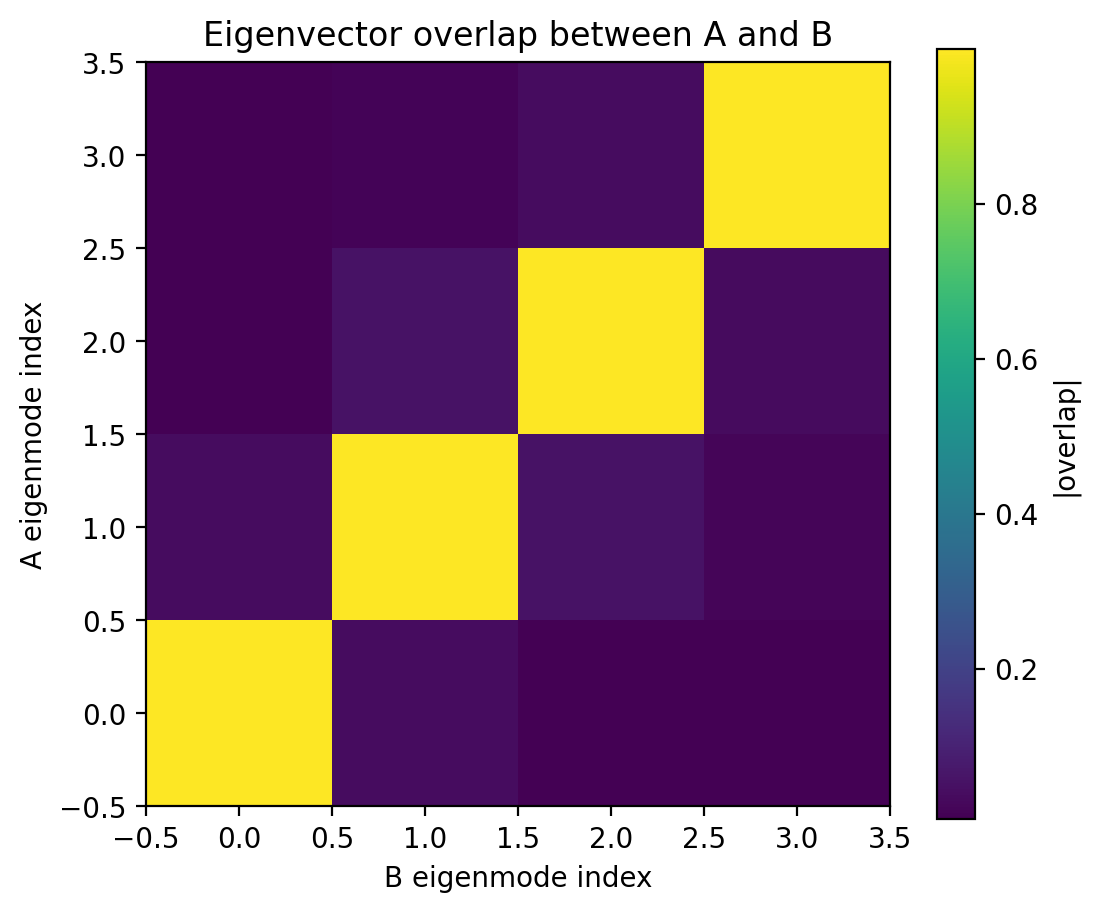

In [13]:
plt.figure(figsize=(6, 5))
plt.imshow(results.eigenvector_overlap, origin="lower", cmap="viridis")
plt.colorbar(label="|overlap|")
plt.xlabel("B eigenmode index")
plt.ylabel("A eigenmode index")
plt.title("Eigenvector overlap between A and B")
plt.show()

# Generalized Modes Analysis

In [14]:
print(format_mode_summary(results))

Mode 1
rho = 1.14
sigma ratio = 1.07
status = degraded
direction:
0.881 omega_b +0.469 theta_s_1e2 (theta_s_100 in B) +0.063 omega_cdm -0.007 delta_DMDE

Mode 2
rho = 0.934
sigma ratio = 0.967
status = improved
direction:
0.937 omega_b -0.348 theta_s_1e2 (theta_s_100 in B) +0.019 omega_cdm -0.002 delta_DMDE

Mode 3
rho = 0.616
sigma ratio = 0.785
status = improved
direction:
0.825 omega_cdm -0.539 theta_s_1e2 (theta_s_100 in B) +0.146 omega_b -0.088 delta_DMDE

Mode 4
rho = 0.0136
sigma ratio = 0.116
status = improved
direction:
0.937 omega_b +0.322 omega_cdm +0.120 theta_s_1e2 (theta_s_100 in B) +0.067 delta_DMDE


In [15]:
# if interesrted only in one specific mode you can do:
print(format_mode_summary(results, mode_index=1))

Mode 1
rho = 1.14
sigma ratio = 1.07
status = degraded
direction:
0.881 omega_b +0.469 theta_s_1e2 (theta_s_100 in B) +0.063 omega_cdm -0.007 delta_DMDE


In [16]:
print(format_mode_direction(results))

Mode 1: 0.881 omega_b +0.469 theta_s_1e2 (theta_s_100 in B) +0.063 omega_cdm -0.007 delta_DMDE
Mode 2: 0.937 omega_b -0.348 theta_s_1e2 (theta_s_100 in B) +0.019 omega_cdm -0.002 delta_DMDE
Mode 3: 0.825 omega_cdm -0.539 theta_s_1e2 (theta_s_100 in B) +0.146 omega_b -0.088 delta_DMDE
Mode 4: 0.937 omega_b +0.322 omega_cdm +0.120 theta_s_1e2 (theta_s_100 in B) +0.067 delta_DMDE


## Plot all generalized modes as 1D Hist

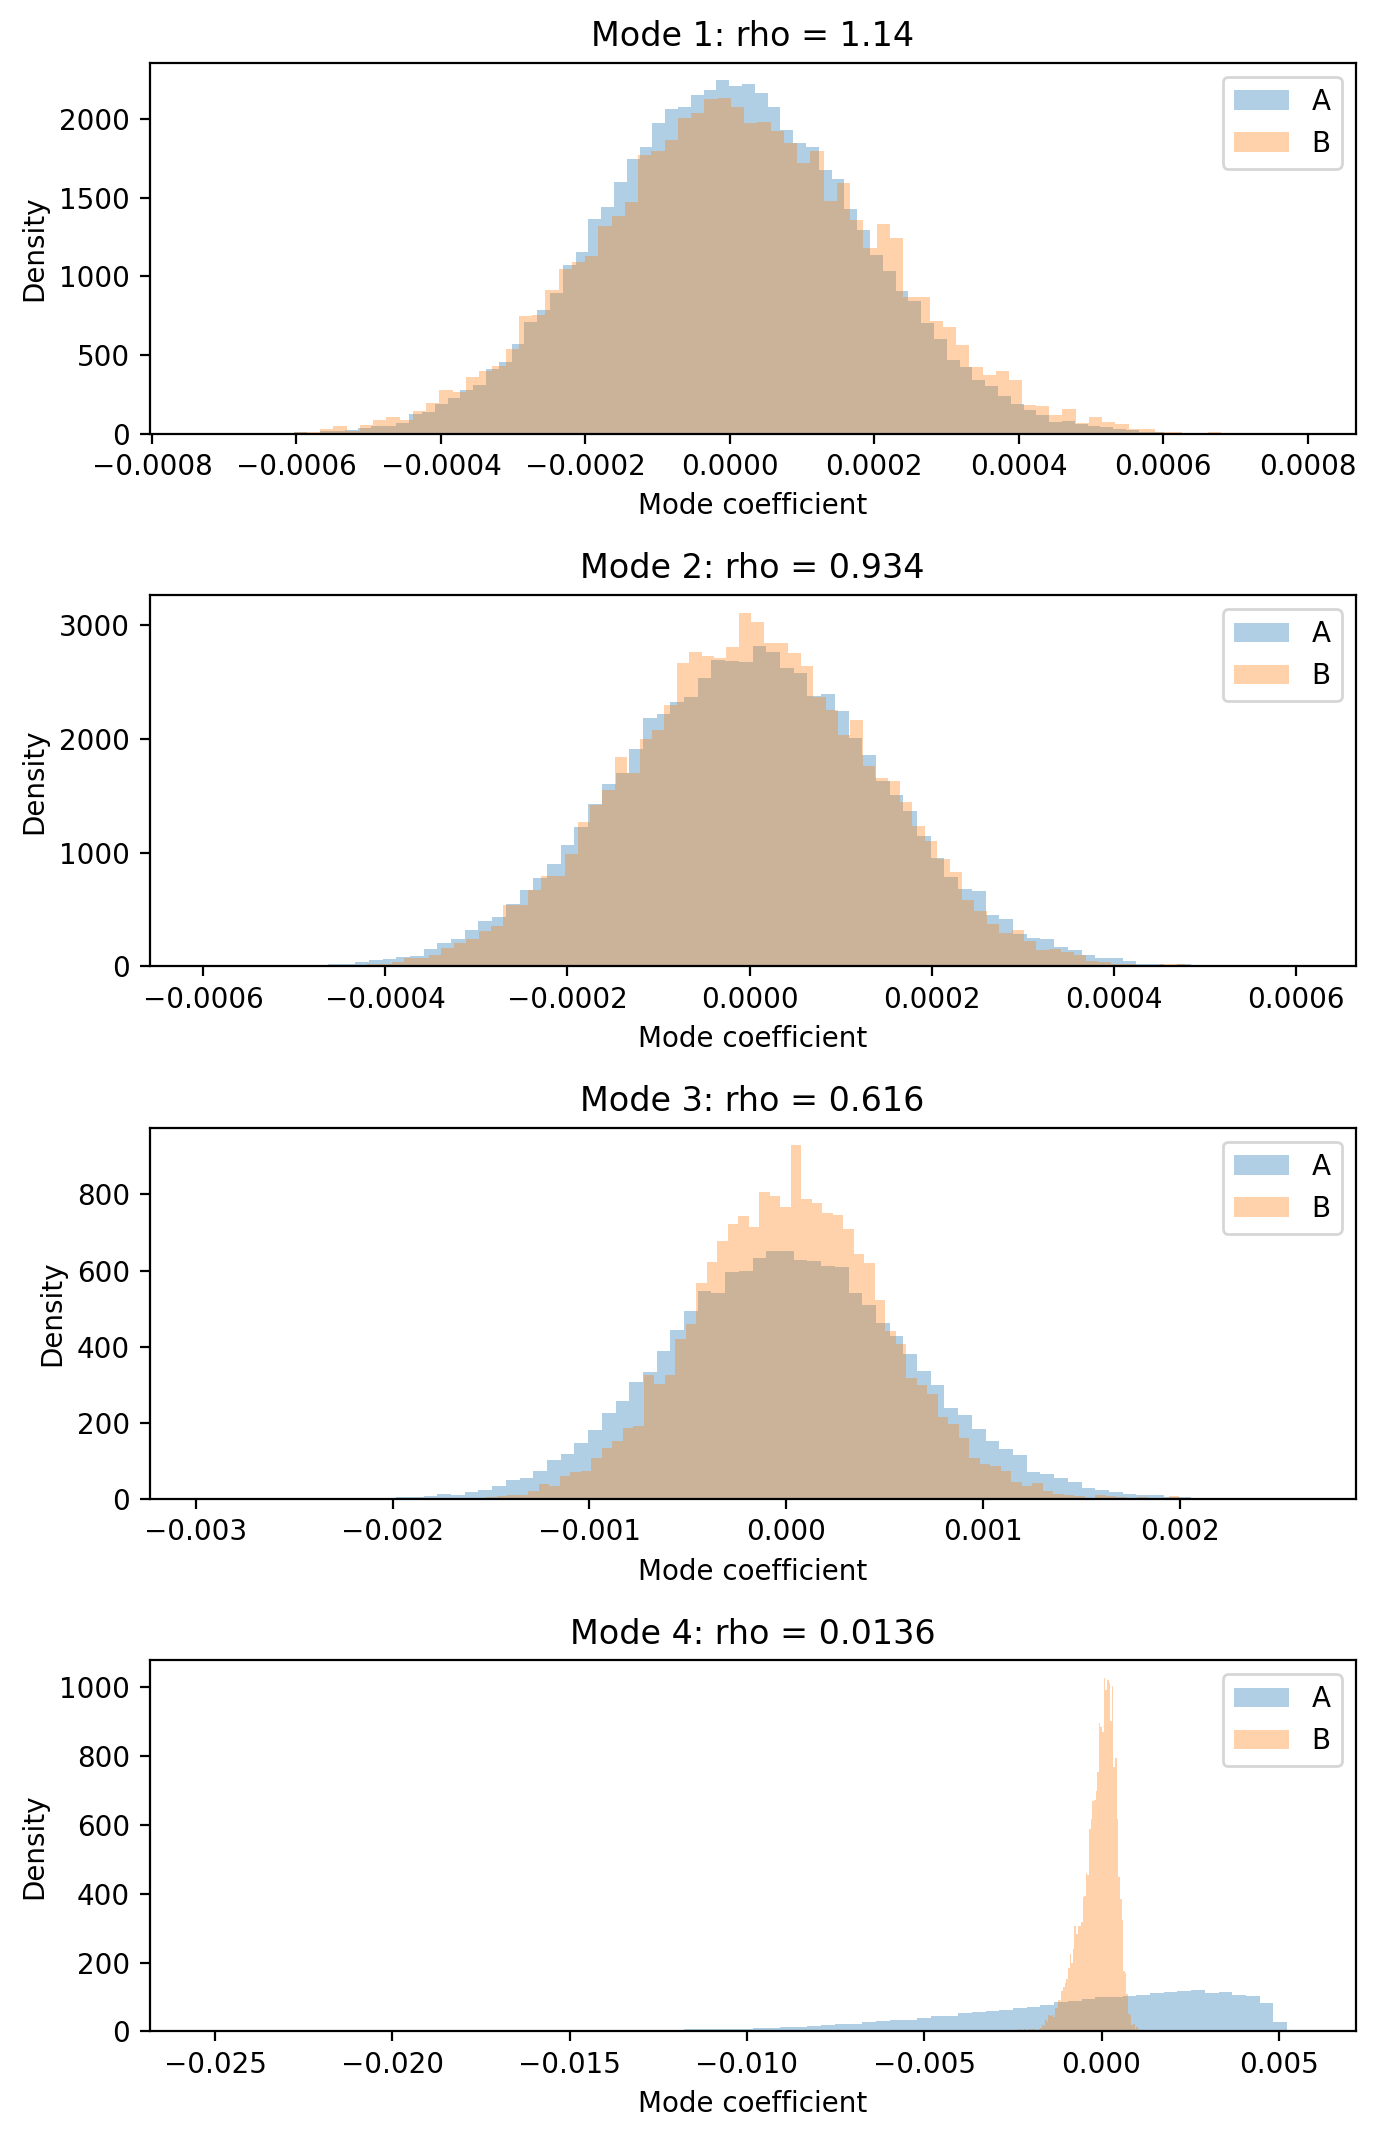

In [17]:
modes_a, modes_b = get_mode_samples(
    sample_a,
    sample_b,
    results,
)

n_modes = modes_a.shape[1]
fig, axes = plt.subplots(n_modes, 1, figsize=(7, 2.7 * n_modes), sharex=False)

if n_modes == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.hist(modes_a[:, i], bins=80, density=True, alpha=0.35, label="A")
    ax.hist(modes_b[:, i], bins=80, density=True, alpha=0.35, label="B")
    ax.set_title(f"Mode {i+1}: rho = {results.degradation_factors[i]:.3g}")
    ax.set_xlabel("Mode coefficient")
    ax.set_ylabel("Density")
    ax.legend()

fig.tight_layout()

## Add All Generalized Modes As GetDist Derived Parameters

In [18]:
sample_a_modes = add_all_mode_derived_parameters(
    sample_a,
    results,
    dataset="reference",
)

sample_b_modes = add_all_mode_derived_parameters(
    sample_b,
    results,
    dataset="alternative",
)

In [19]:
sample_a_modes.getParamNames().list()[-4:]

['mode_1', 'mode_2', 'mode_3', 'mode_4']

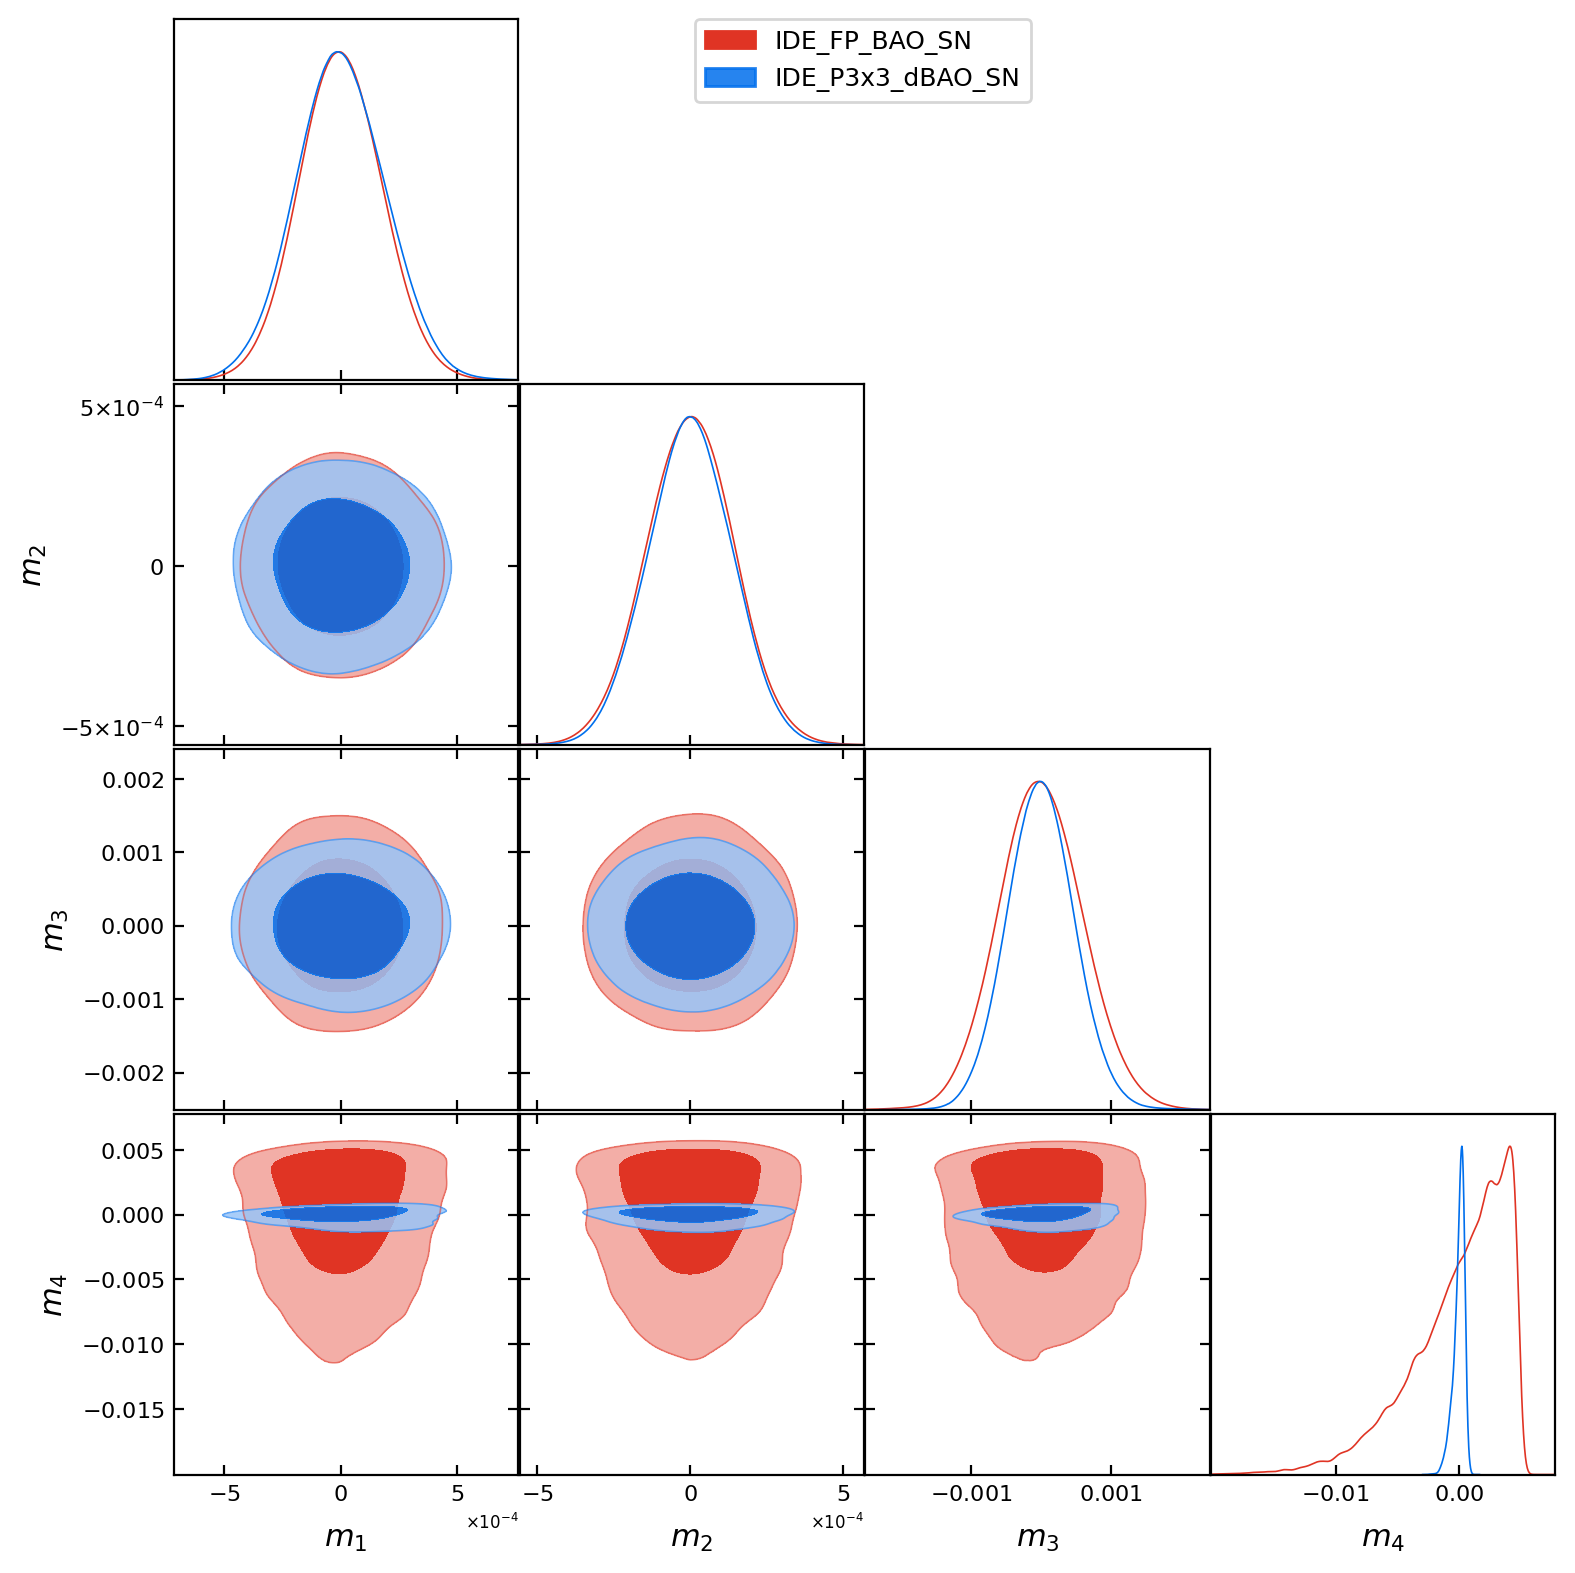

In [20]:
g = plots.get_subplot_plotter()
g.triangle_plot([sample_a_modes, sample_b_modes], ["mode_1", "mode_2", "mode_3", "mode_4"], filled=True)